In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from GMM import GMM
import cv2
import os
import matplotlib.pyplot as plt


In [2]:
def plot(title):
    '''
    Draw the data points and the fitted mixture model.
    input:
        - title: title of plot and name with which it will be saved.
    '''
    fig = plt.figure(figsize=(8, 8))
    ax = fig.gca()
    ax.scatter(X[:, 0], X[:, 1], s=3, alpha=0.4)
    ax.scatter(gmm.mu[:, 0], gmm.mu[:, 1], c=gmm.colors)
    gmm.draw(ax, lw=3)
    ax.set_xlim((-12, 12))
    ax.set_ylim((-12, 12))
    
    plt.title(title)
    plt.savefig(title.replace(':', '_'))
    # plt.show()
    # plt.clf()

(23716, 2)


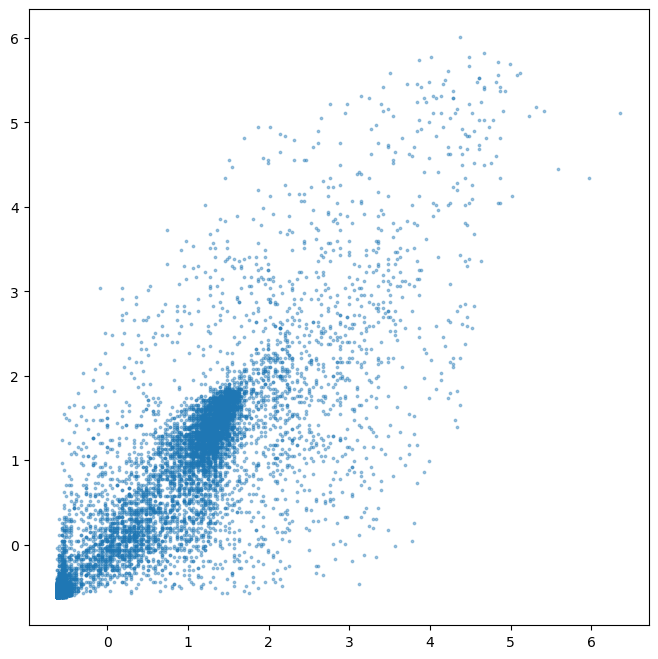

In [6]:


directory = 'im_gbm_multispec'
filenames = ['IM17_axt1c.tiff', 'IM17_axt1FLAIR.tiff']


image = [cv2.imread(os.path.join(directory, filename), cv2.IMREAD_ANYCOLOR) for filename in filenames]
image = [cv2.resize(im, None, fx = 0.3, fy = 0.3)[:, :, np.newaxis] for im in image]
image = np.concatenate(image, axis=2)
nf, nc, _ = image.shape

X = image.reshape((-1, 2))
X[np.isinf(X)] = 0
X[np.isnan(X)] = 0
print(X.shape)

from sklearn.preprocessing import StandardScaler
X = StandardScaler().fit(X).transform(X)


fig = plt.figure(figsize=(8, 8))
ax = fig.gca()
ax.scatter(X[:, 0], X[:, 1], s=3, alpha=0.4)




Iteration: 1, log-likelihood: -25069.2001
Iteration: 2, log-likelihood: -5915.0316
Iteration: 3, log-likelihood: 11152.0649
Iteration: 4, log-likelihood: 24076.7814
Iteration: 5, log-likelihood: 26423.4259
Iteration: 6, log-likelihood: 27005.4142
Iteration: 7, log-likelihood: 27645.7253
Iteration: 8, log-likelihood: 28043.8481
Iteration: 9, log-likelihood: 28165.7614
Iteration: 10, log-likelihood: 28198.7020
Iteration: 11, log-likelihood: 28212.0784
Iteration: 12, log-likelihood: 28220.4707
Iteration: 13, log-likelihood: 28227.2126
Iteration: 14, log-likelihood: 28233.2479
Iteration: 15, log-likelihood: 28238.9206
Iteration: 16, log-likelihood: 28244.4029
Iteration: 17, log-likelihood: 28249.8100
Iteration: 18, log-likelihood: 28255.2342
Iteration: 19, log-likelihood: 28260.7570
Iteration: 20, log-likelihood: 28266.4517


/var/folders/nw/tp19rnbx6bz35br2s37k9cph0000gn/T/ipykernel_88937/2936297496.py:7: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(8, 8))


Iteration: 21, log-likelihood: 28272.3847
Iteration: 22, log-likelihood: 28278.6132
Iteration: 23, log-likelihood: 28285.1834
Iteration: 24, log-likelihood: 28292.1265
Iteration: 25, log-likelihood: 28299.4564
Iteration: 26, log-likelihood: 28307.1671
Iteration: 27, log-likelihood: 28315.2331
Iteration: 28, log-likelihood: 28323.6109
Iteration: 29, log-likelihood: 28332.2427
Iteration: 30, log-likelihood: 28341.0608
Iteration: 31, log-likelihood: 28349.9930
Iteration: 32, log-likelihood: 28358.9667
Iteration: 33, log-likelihood: 28367.9143
Iteration: 34, log-likelihood: 28376.7778
Iteration: 35, log-likelihood: 28385.5147
Iteration: 36, log-likelihood: 28394.1031
Iteration: 37, log-likelihood: 28402.5463
Iteration: 38, log-likelihood: 28410.8748
Iteration: 39, log-likelihood: 28419.1464
Iteration: 40, log-likelihood: 28427.4447
Iteration: 41, log-likelihood: 28435.8768
Iteration: 42, log-likelihood: 28444.5713
Iteration: 43, log-likelihood: 28453.6730
Iteration: 44, log-likelihood: 284

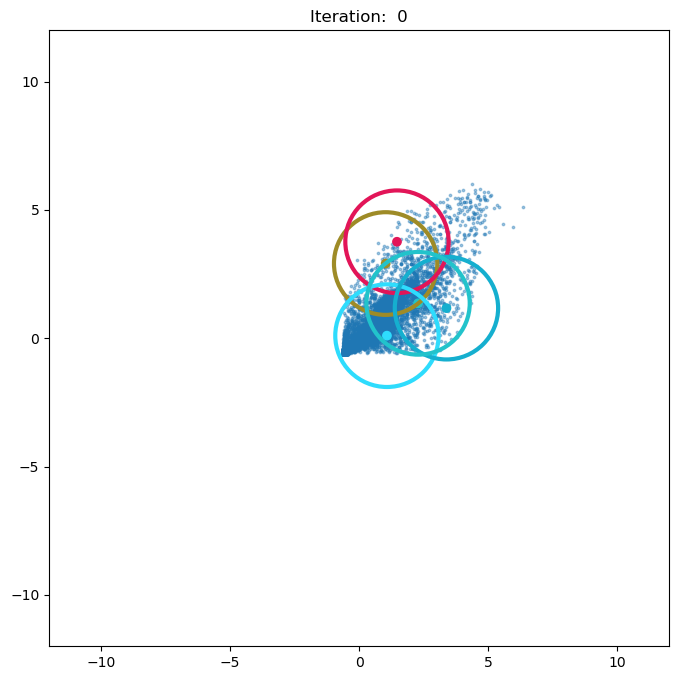

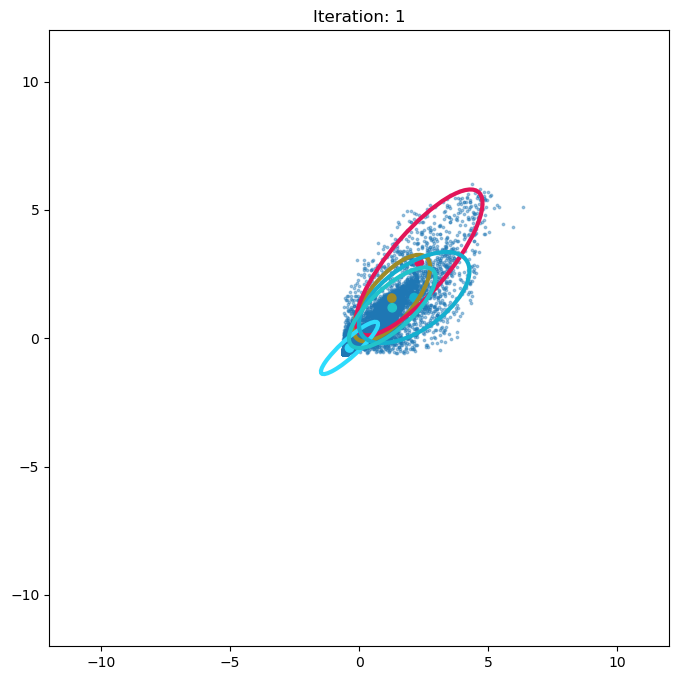

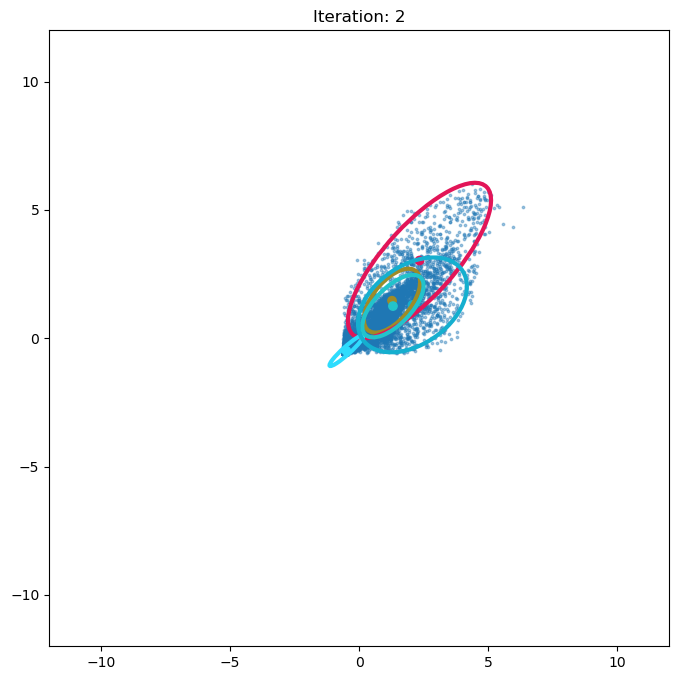

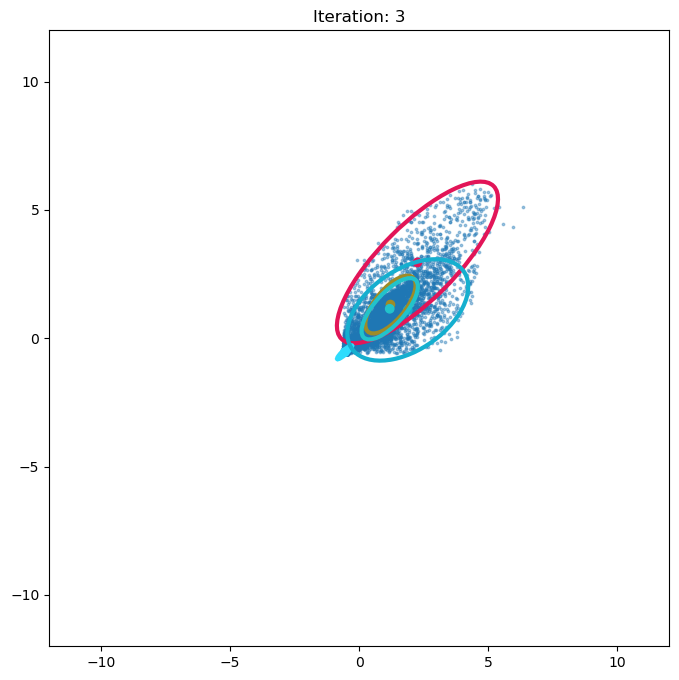

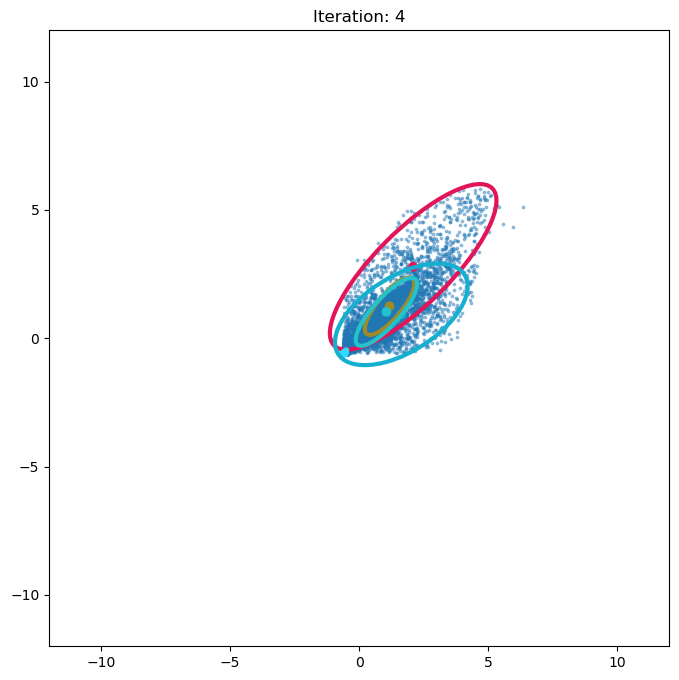

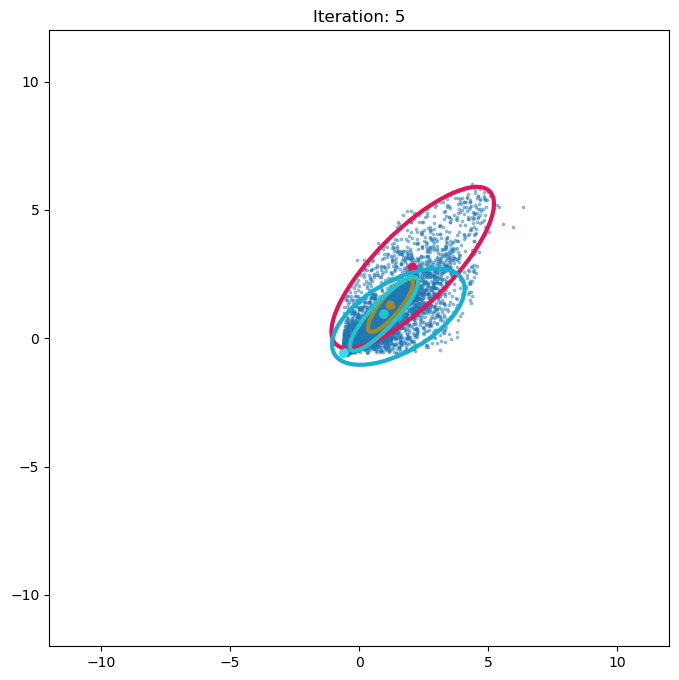

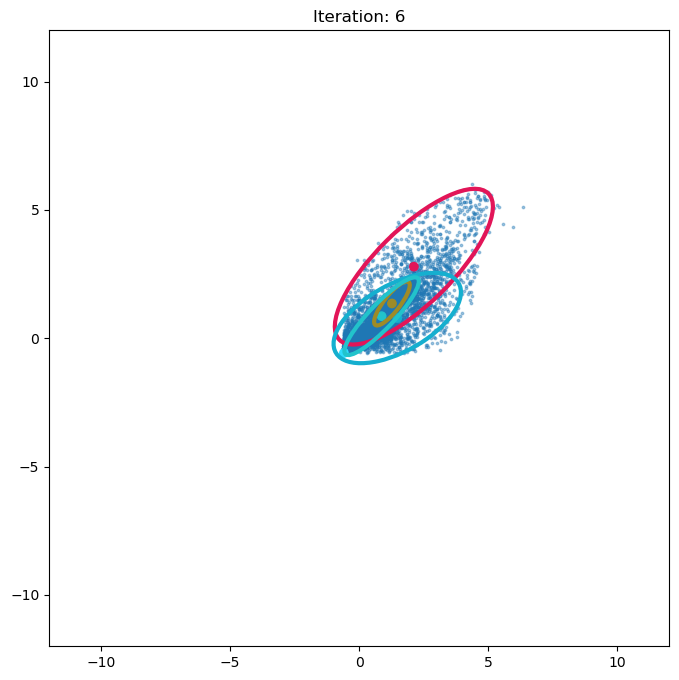

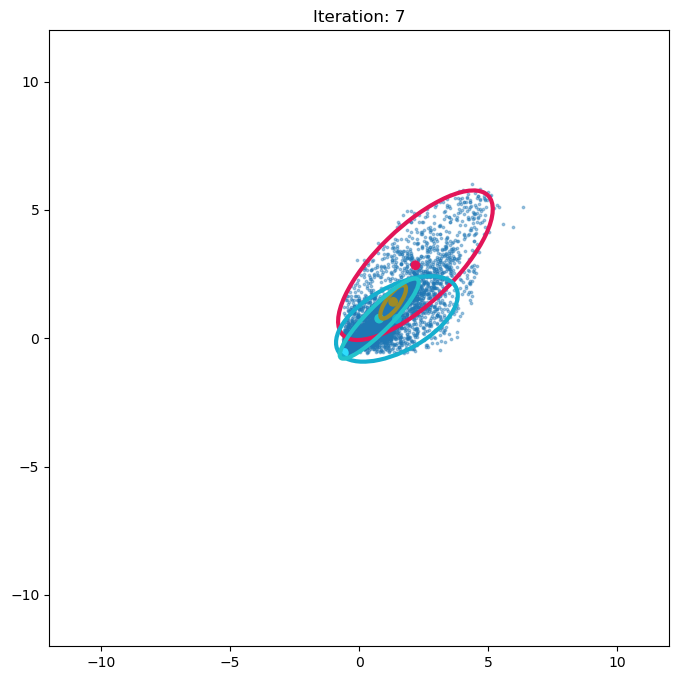

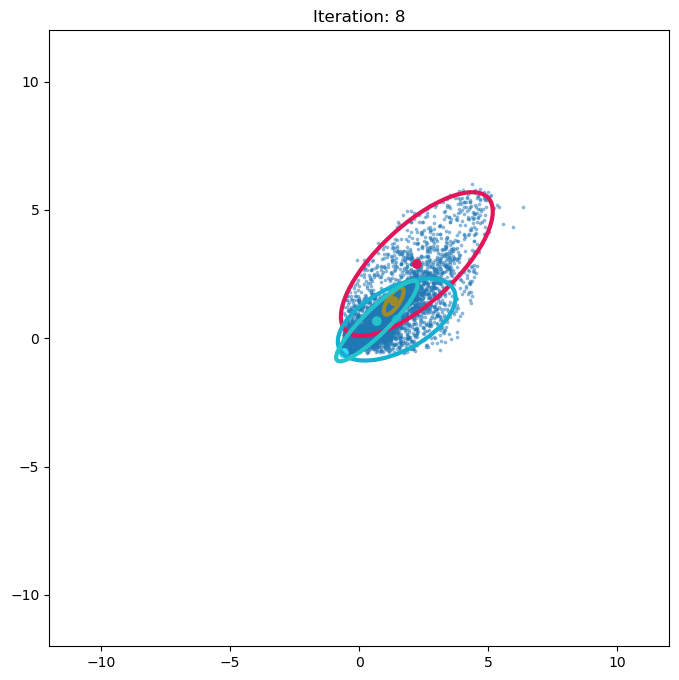

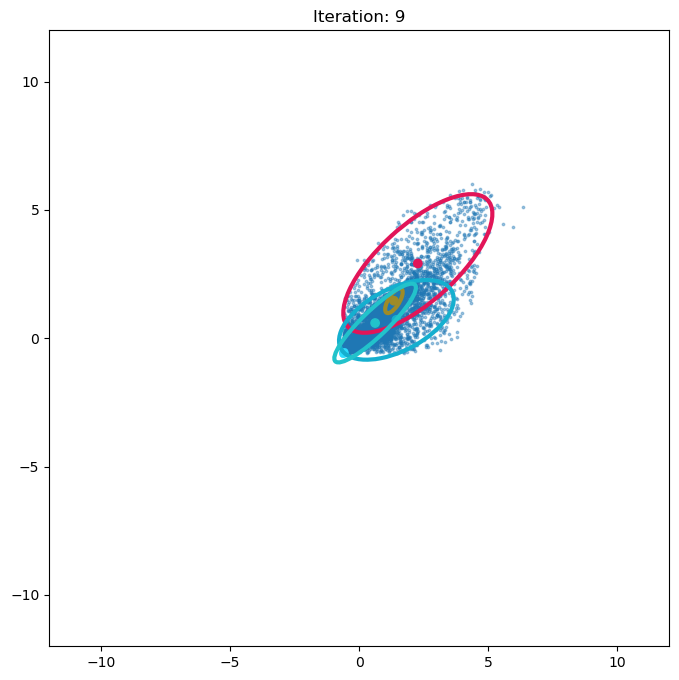

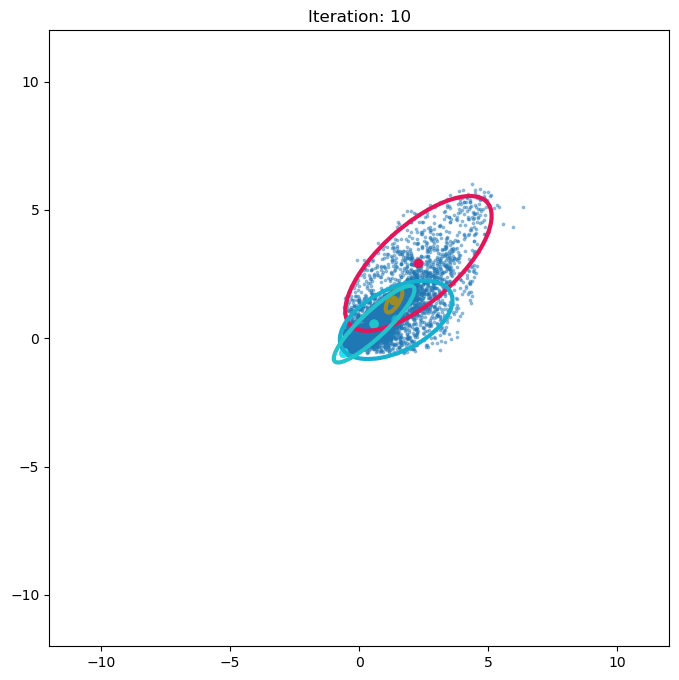

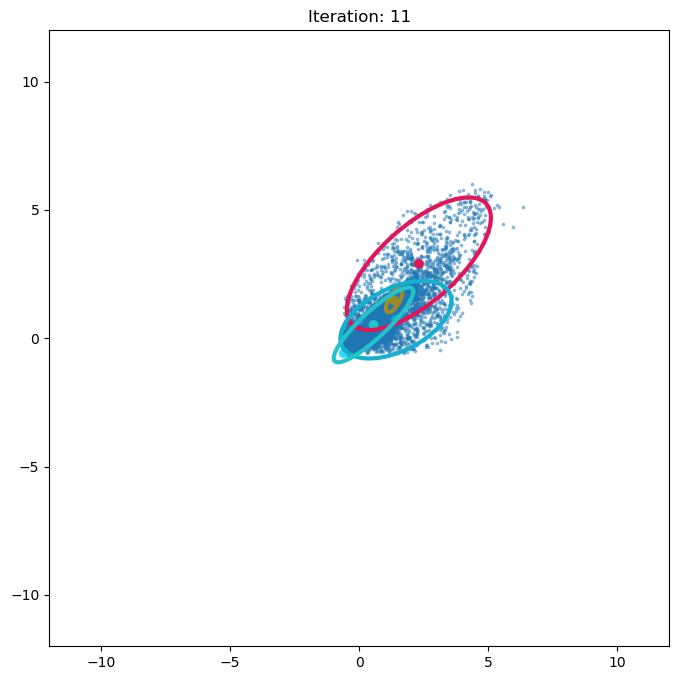

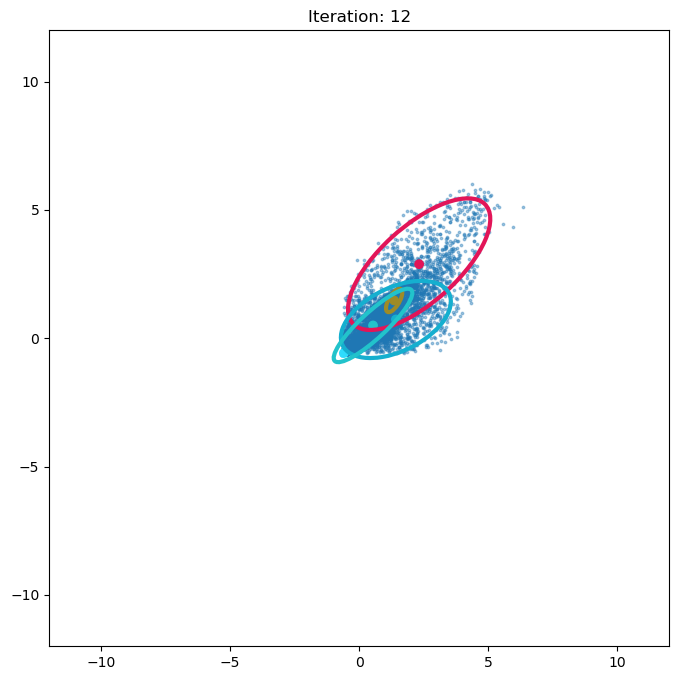

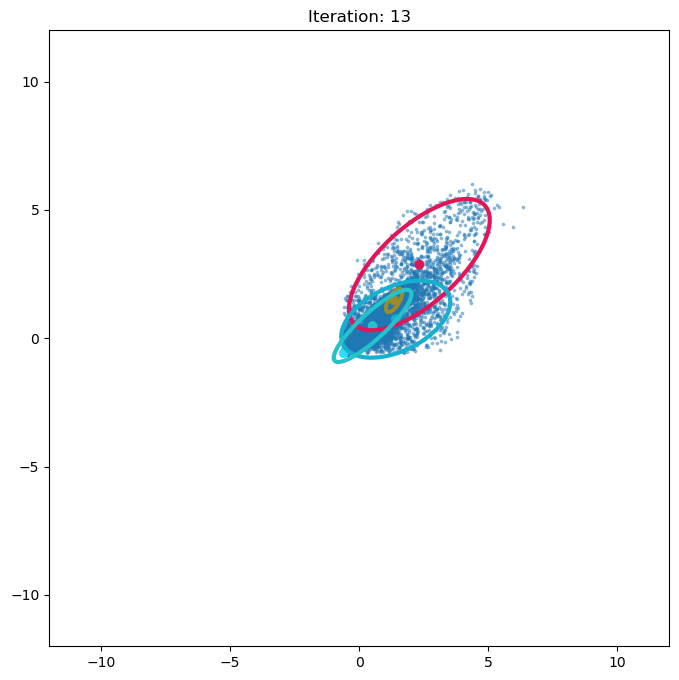

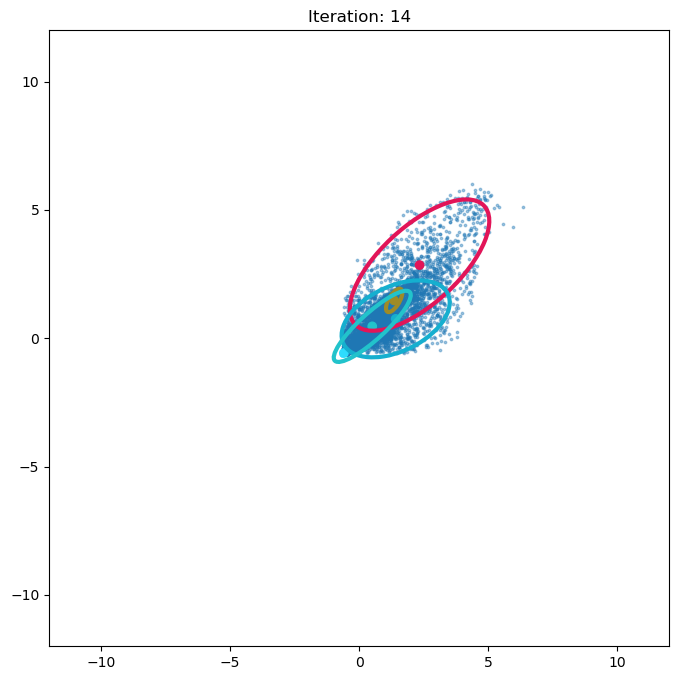

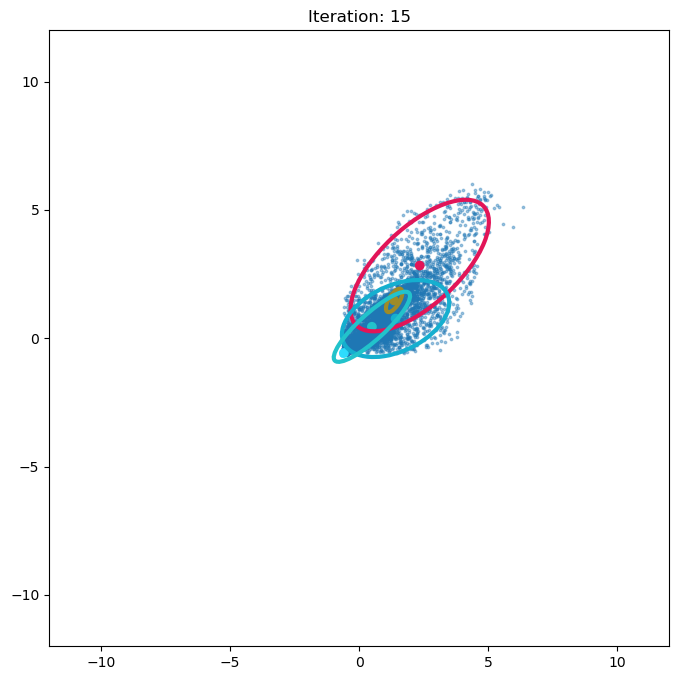

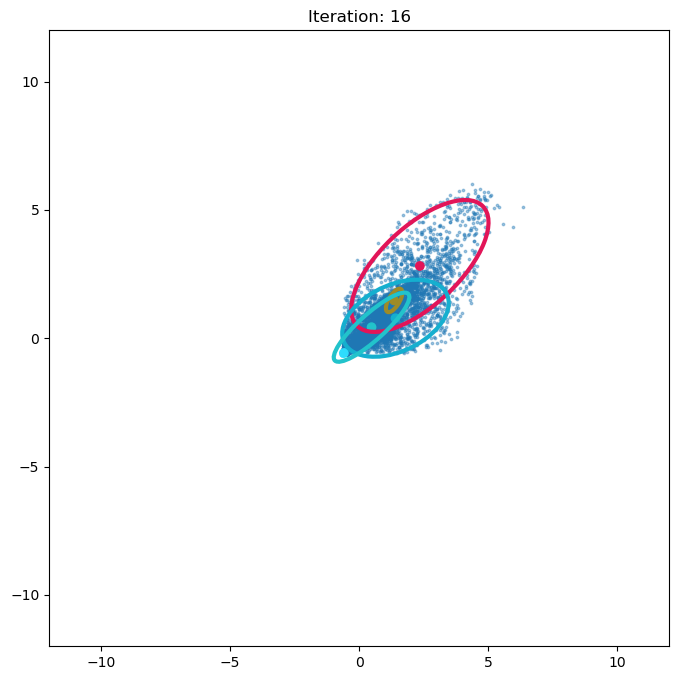

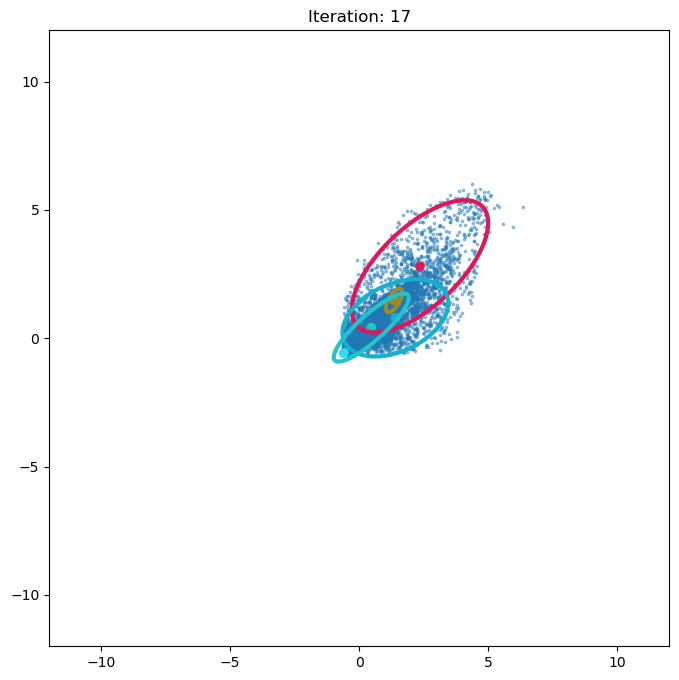

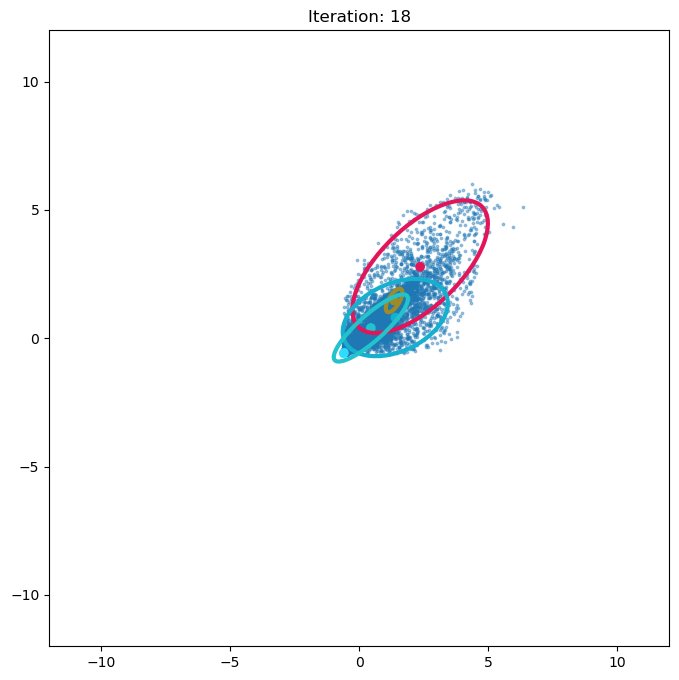

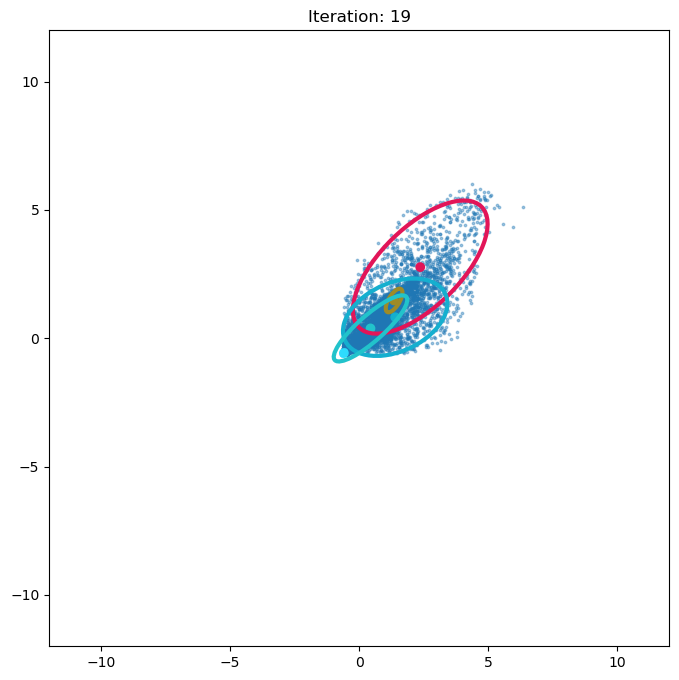

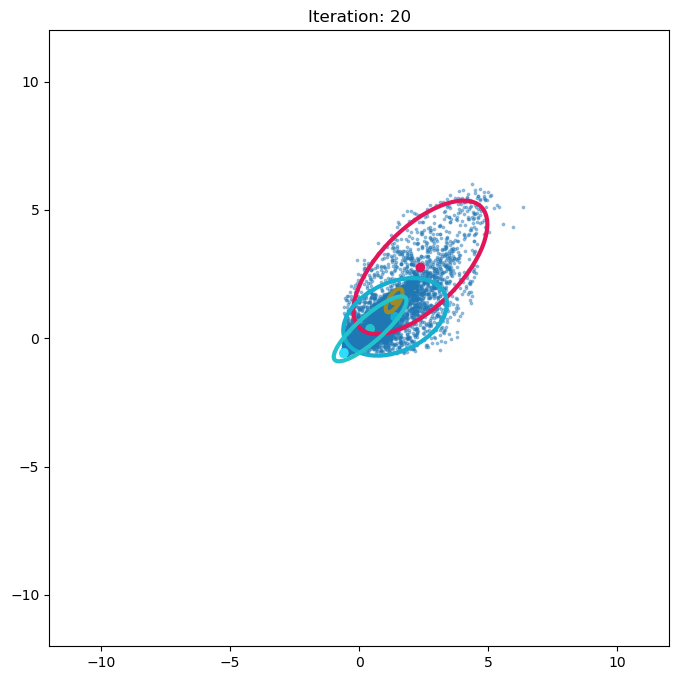

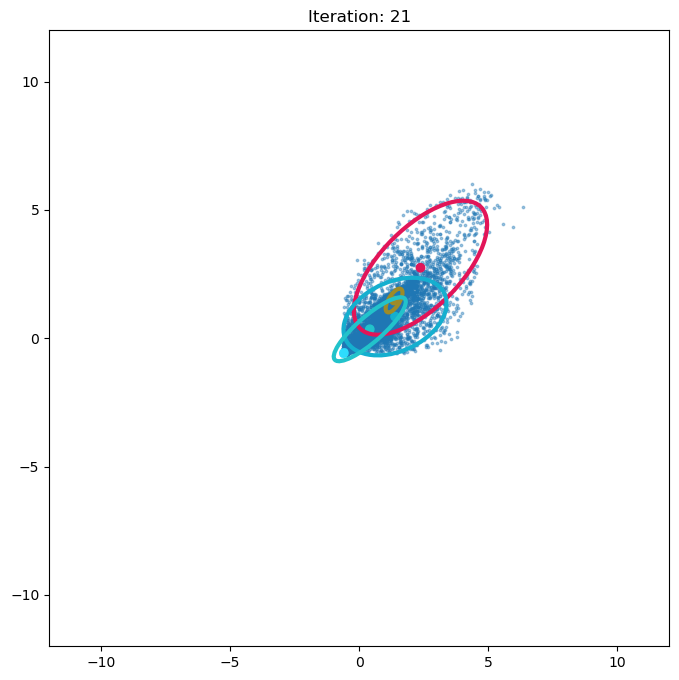

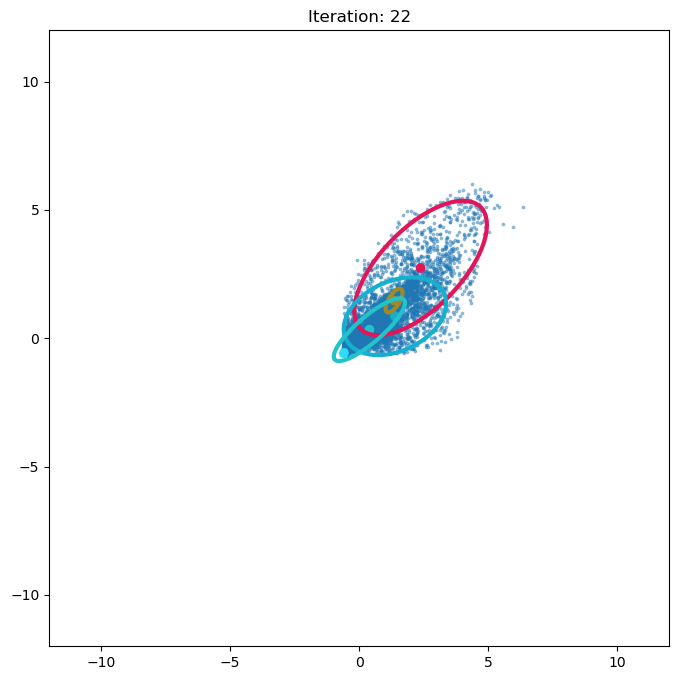

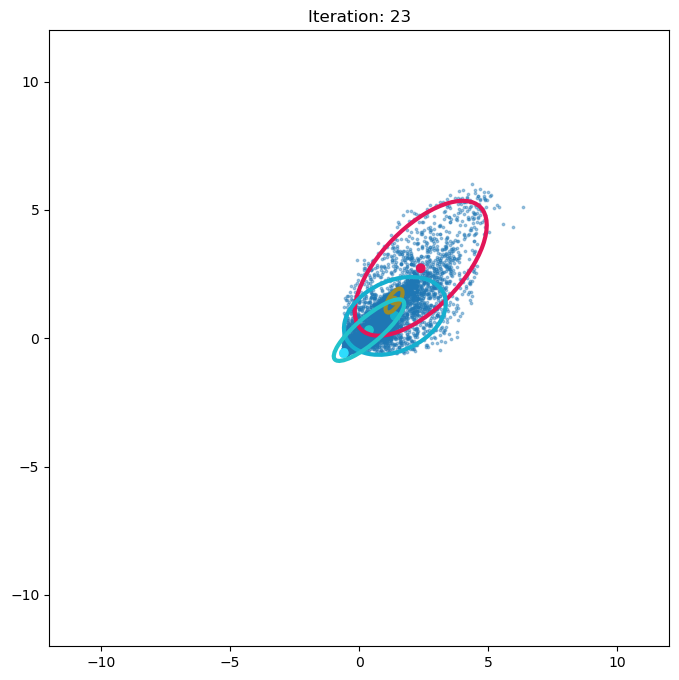

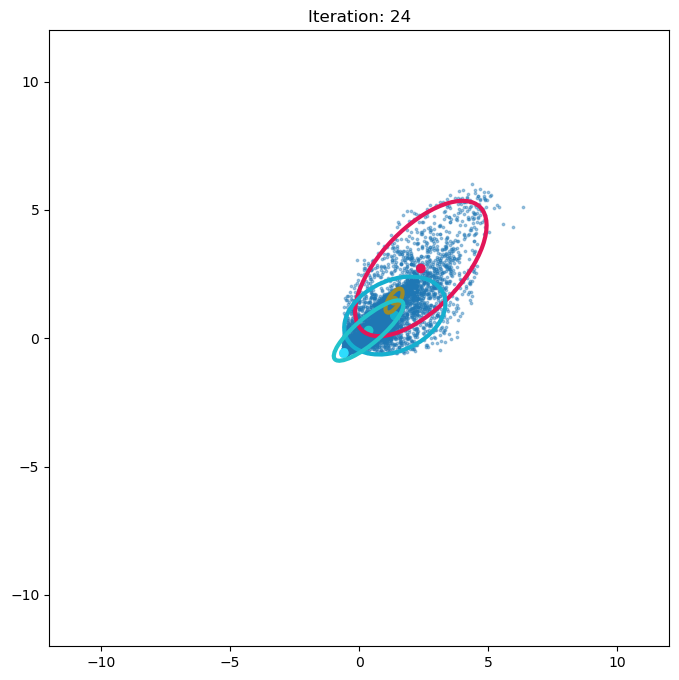

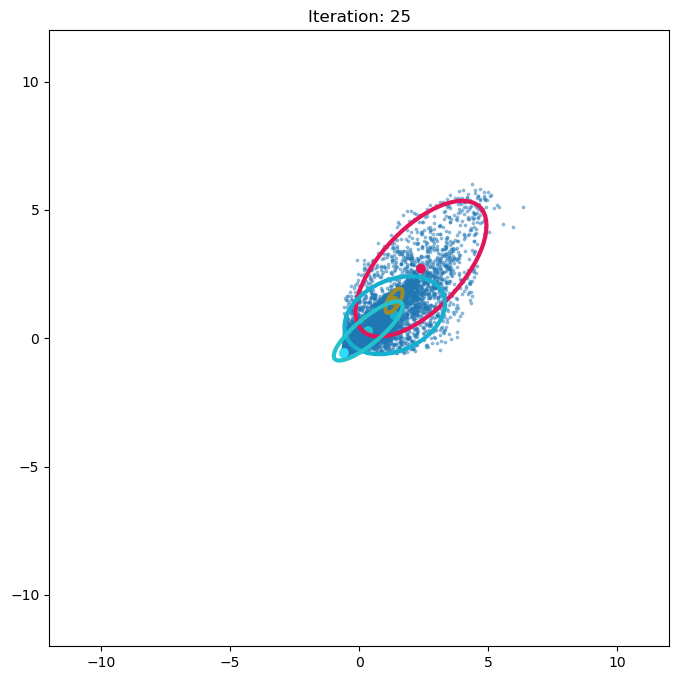

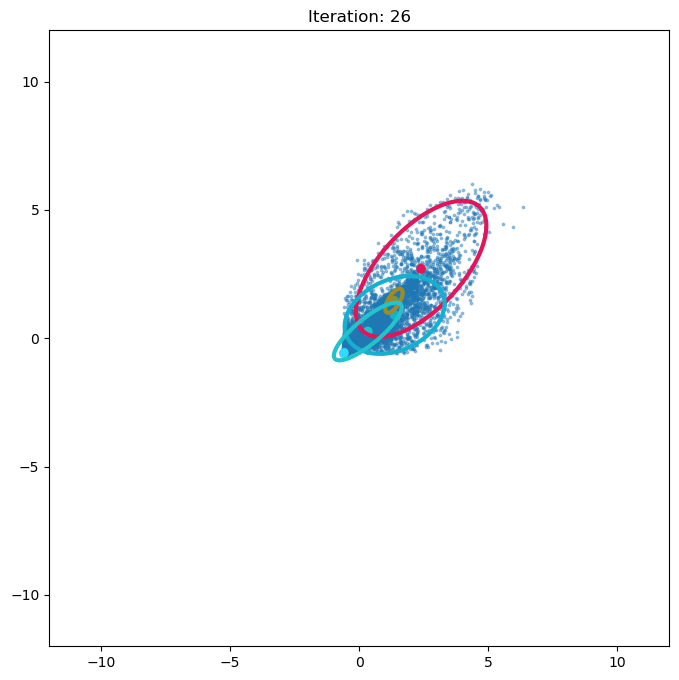

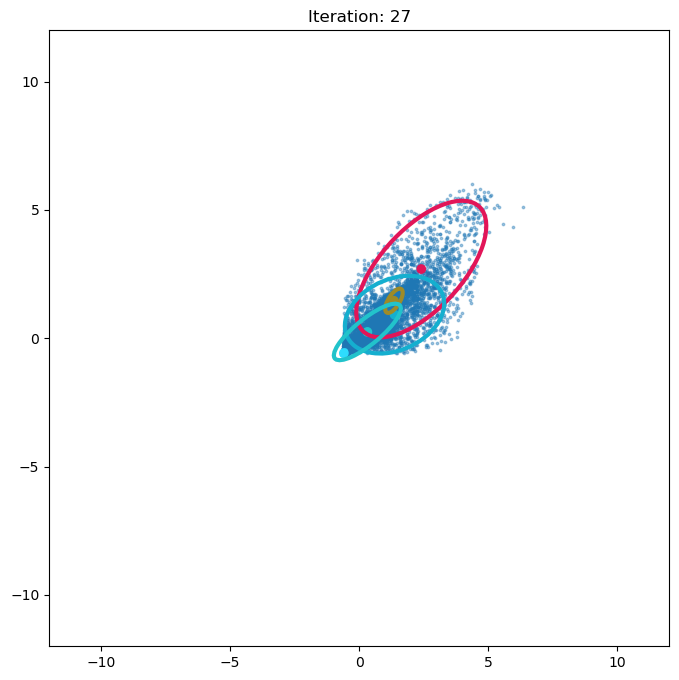

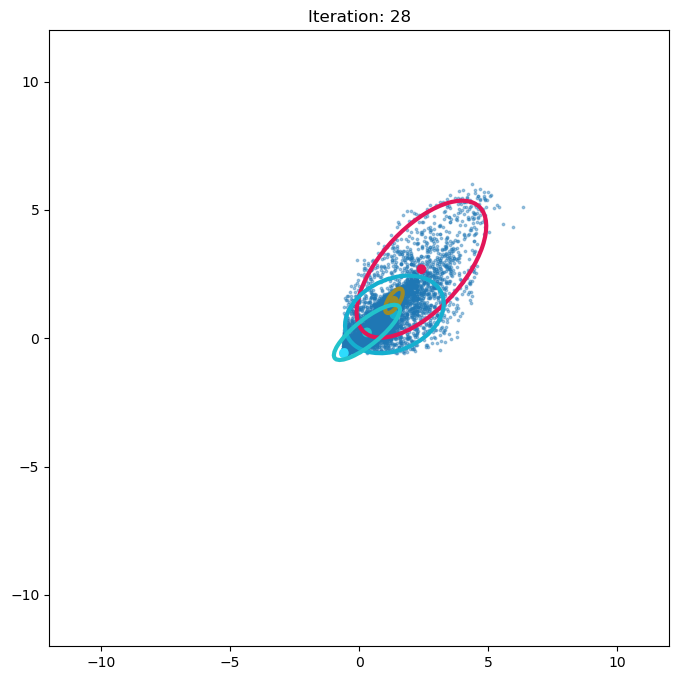

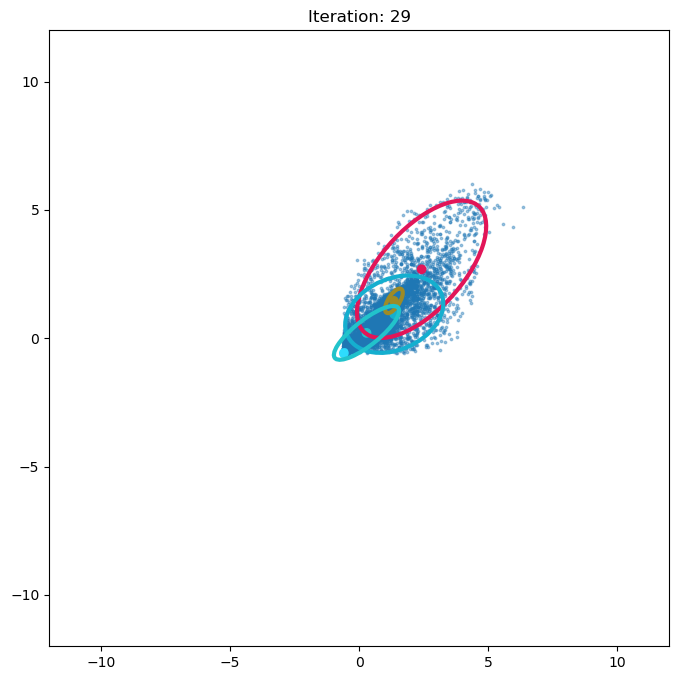

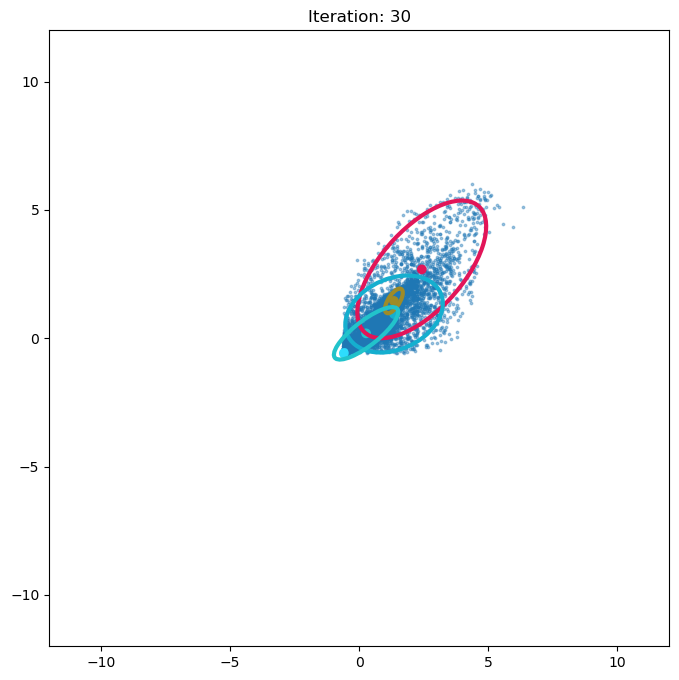

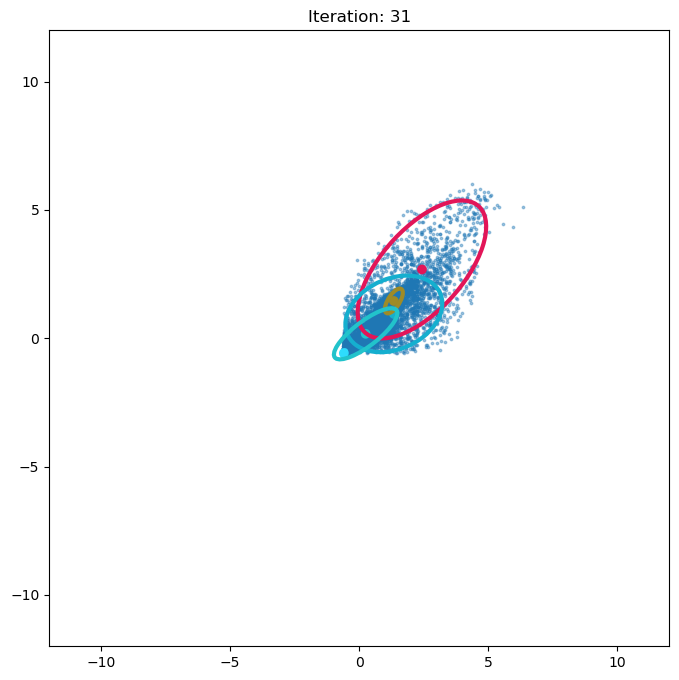

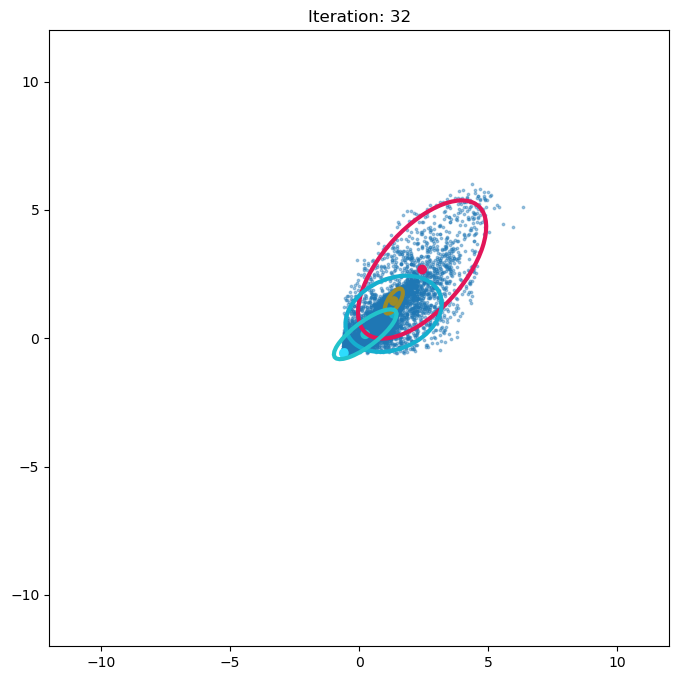

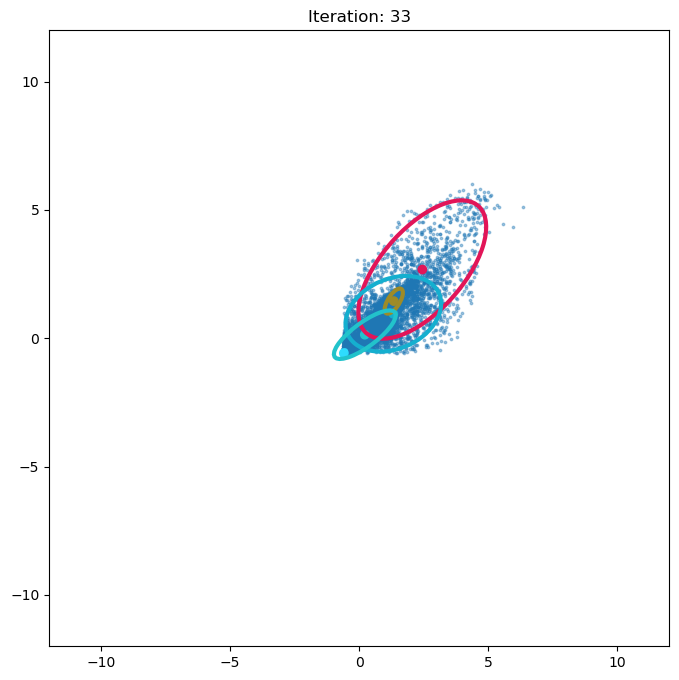

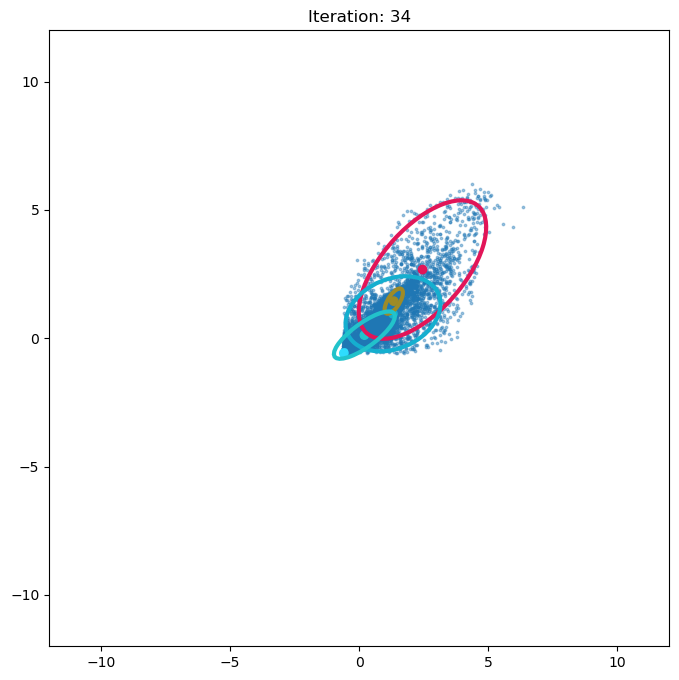

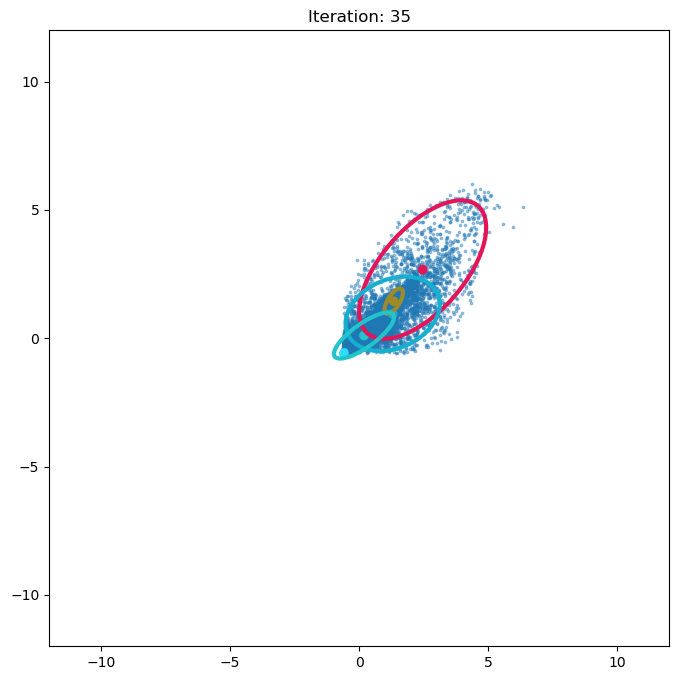

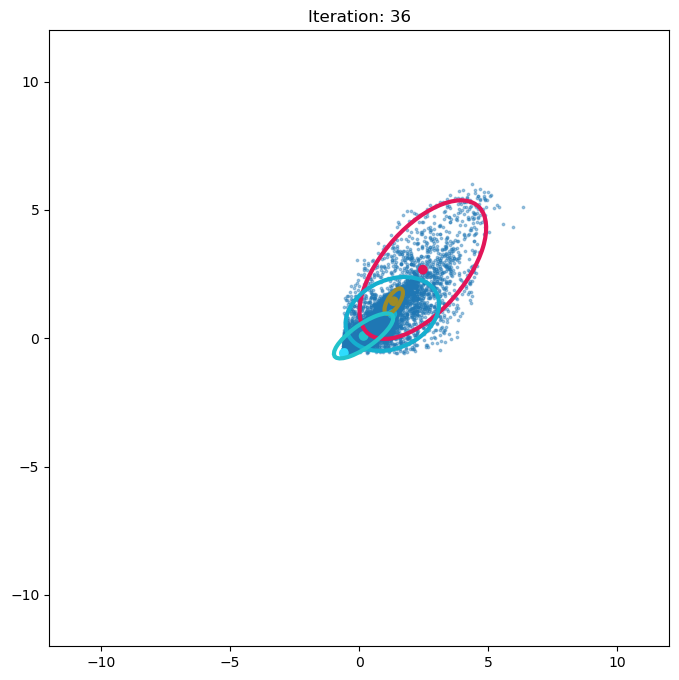

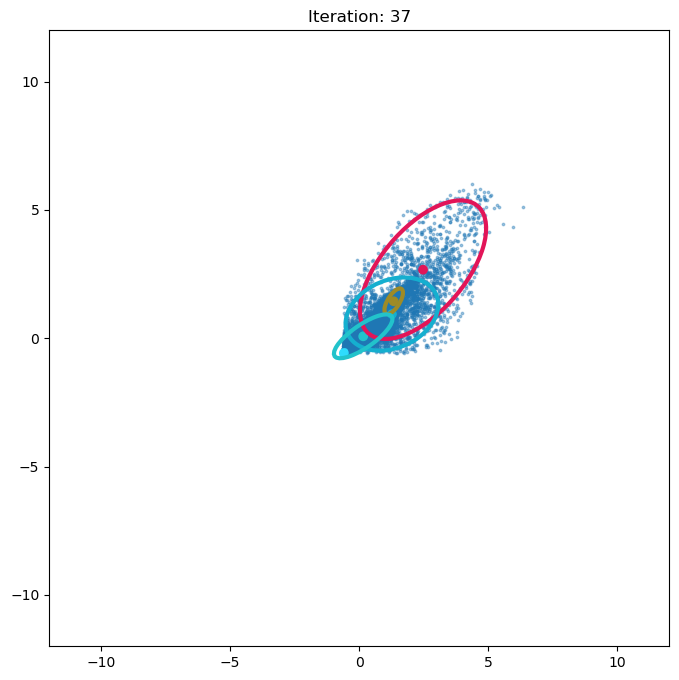

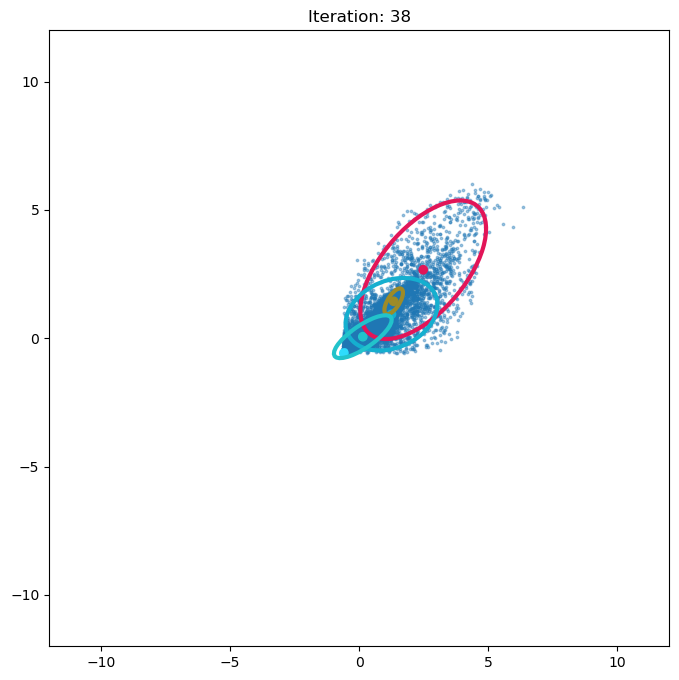

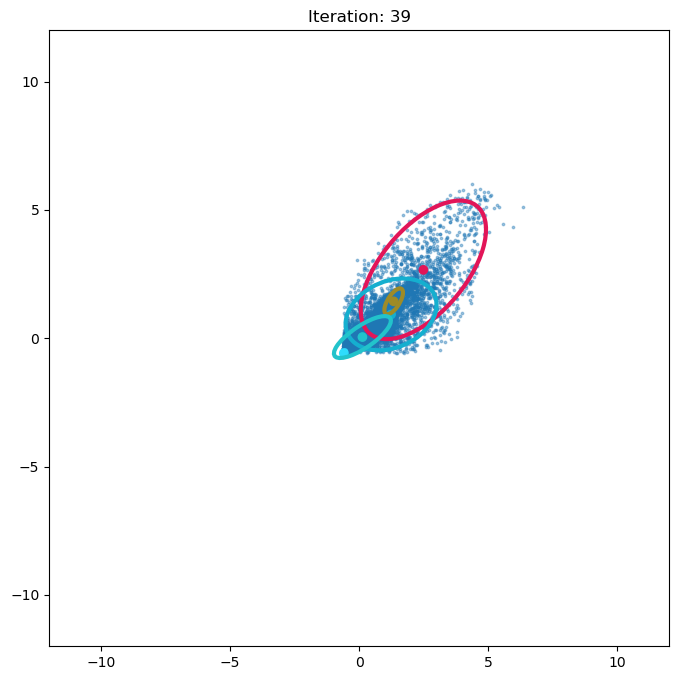

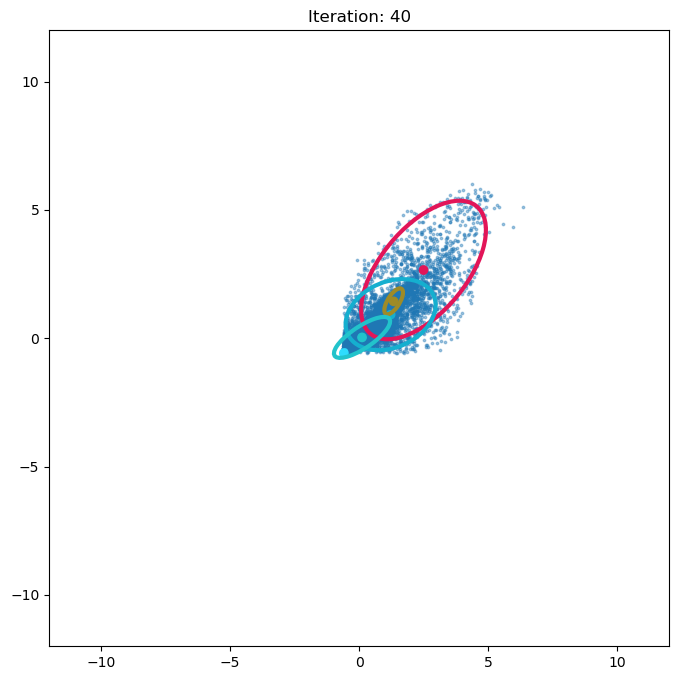

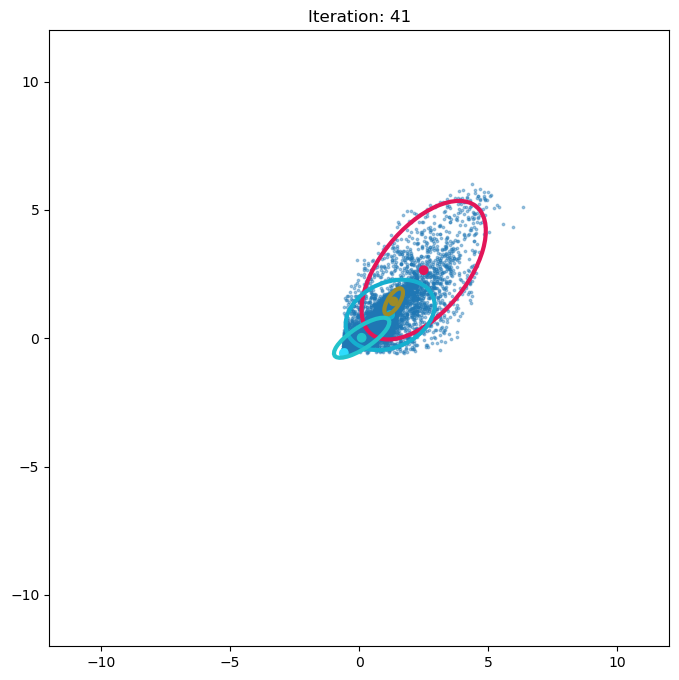

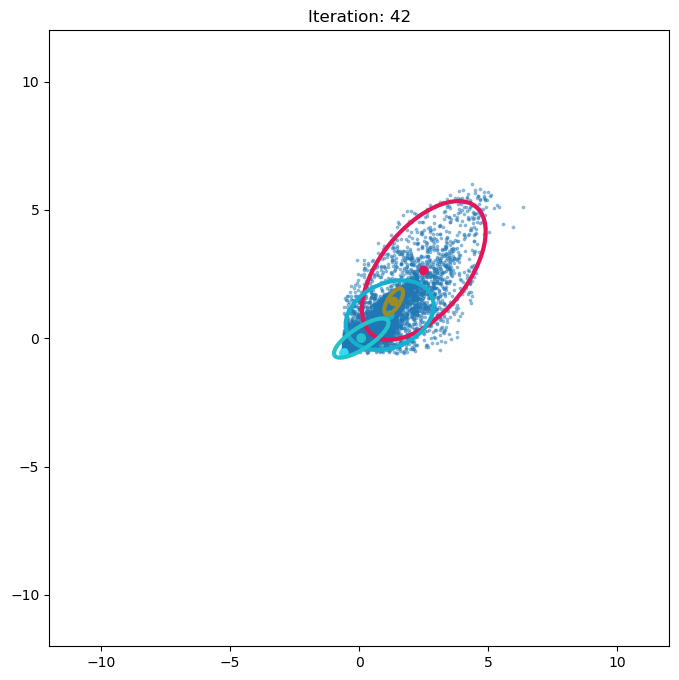

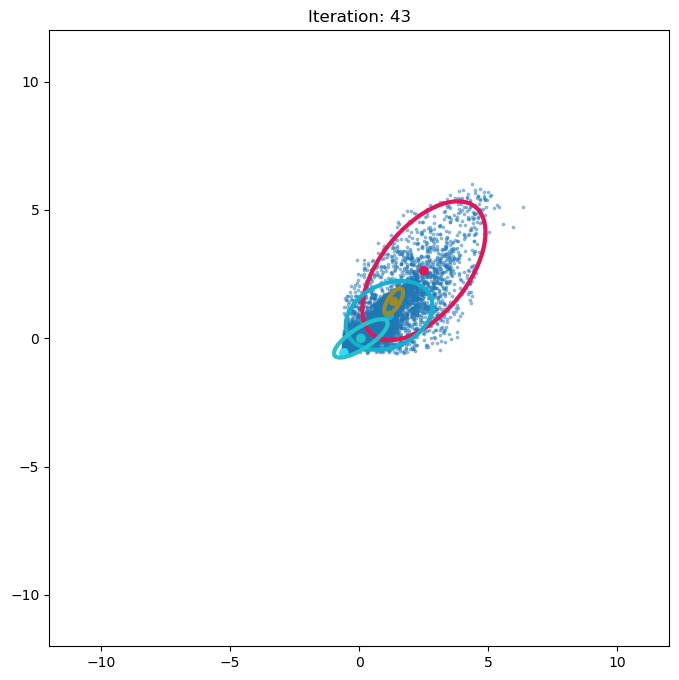

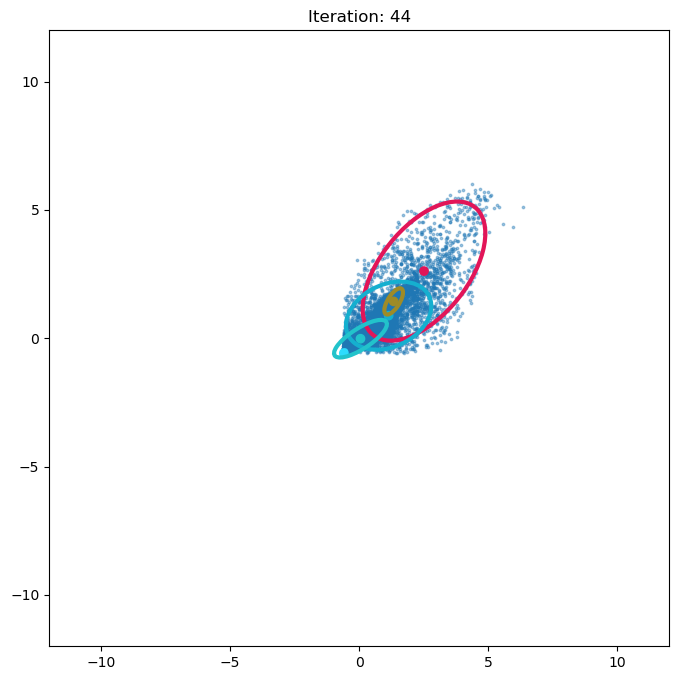

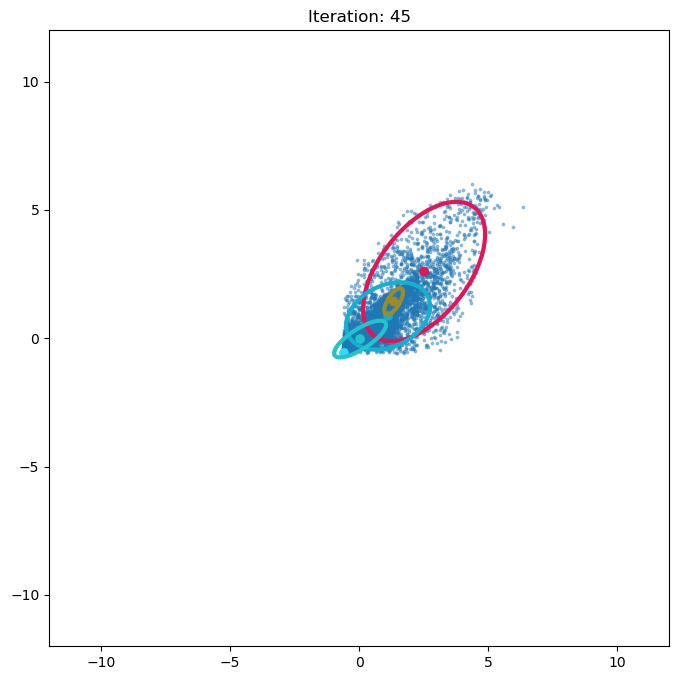

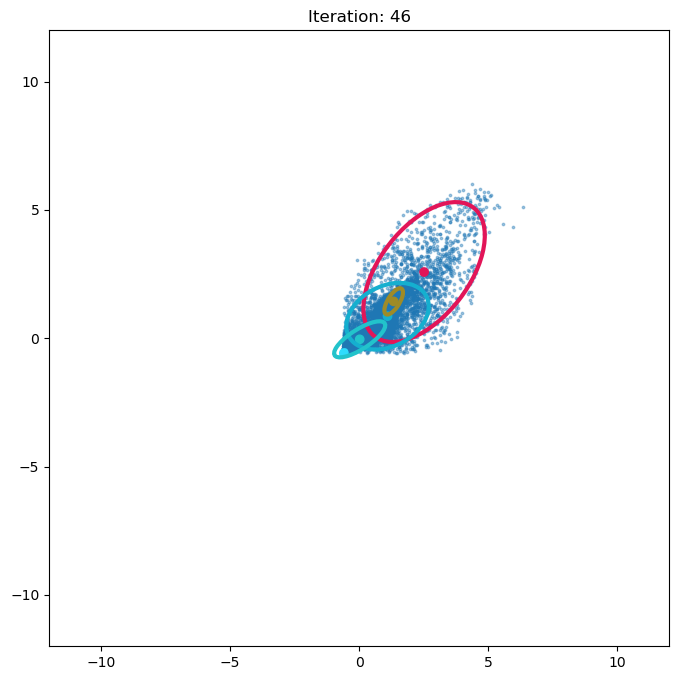

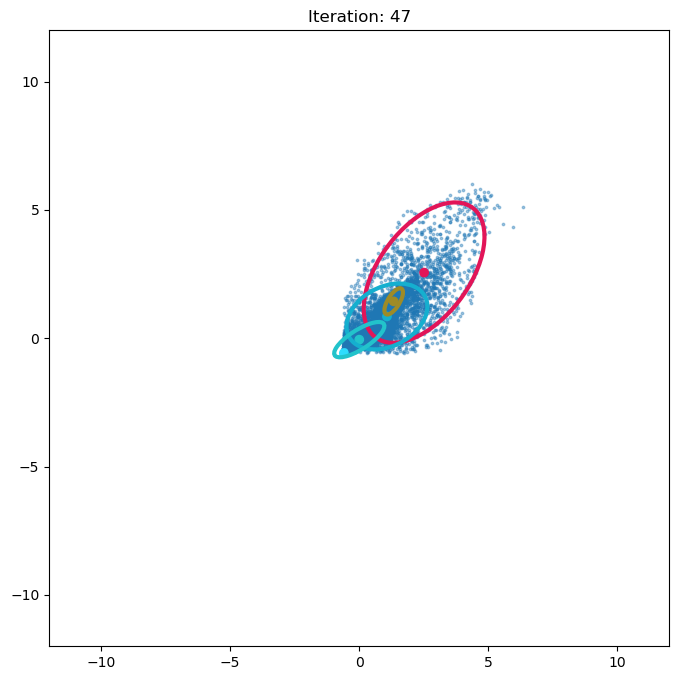

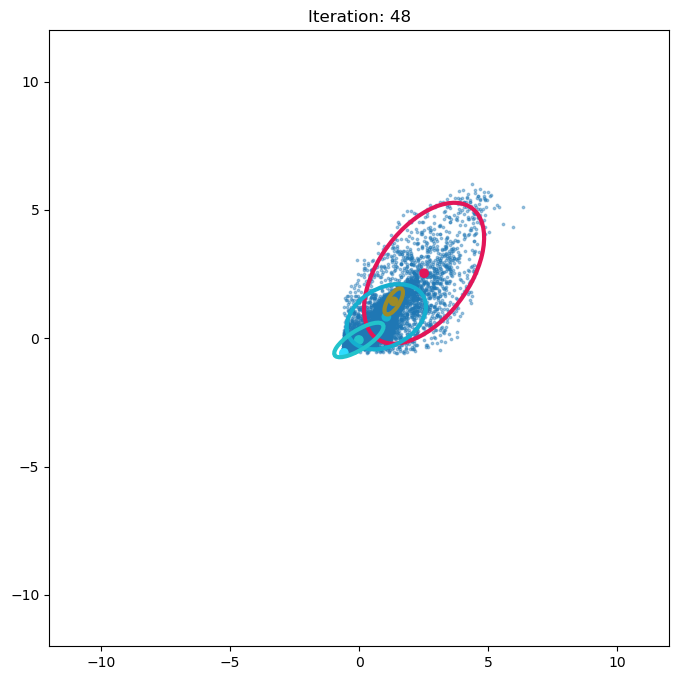

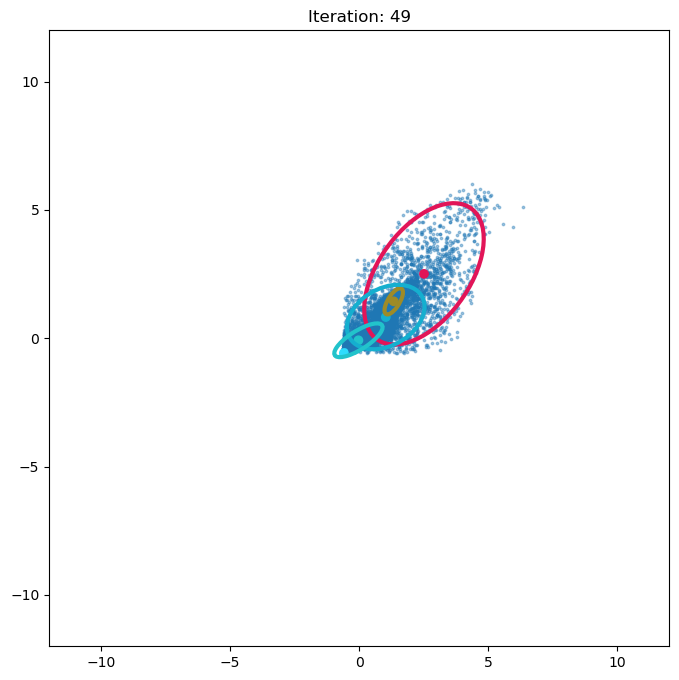

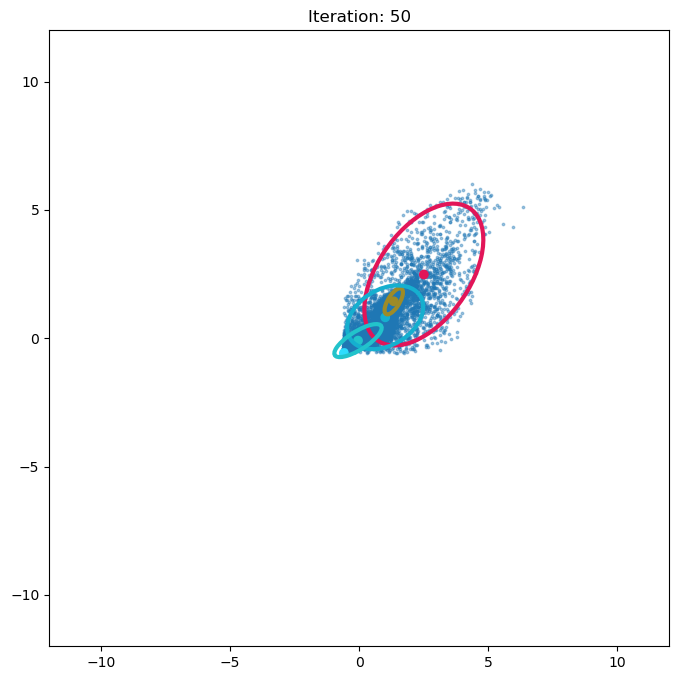

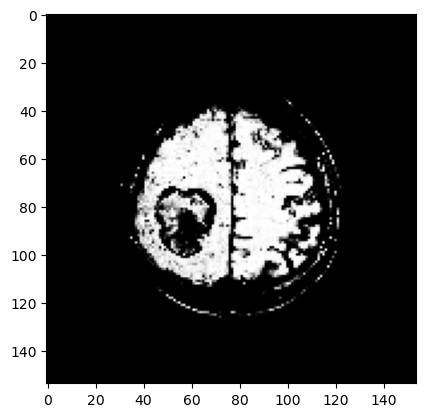

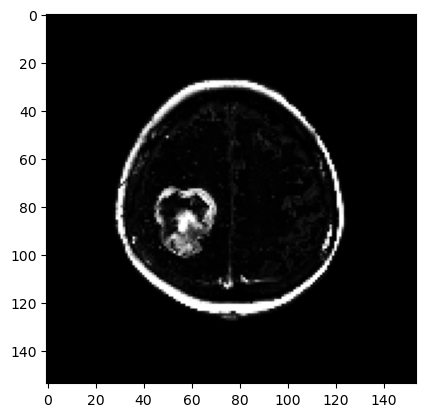

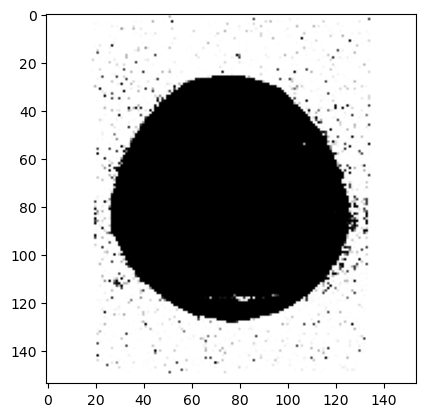

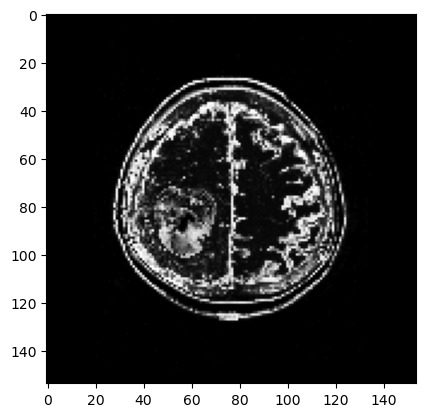

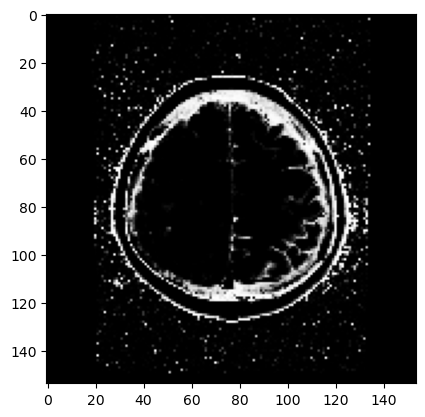

In [7]:
# Training the GMM using EM
k = 5
gmm = GMM(k, 2)
gmm.init_em(X)
num_iters = 50
# Saving log-likelihood
log_likelihood = [gmm.log_likelihood(X)]
# plotting
plot("Iteration:  0")
for e in range(num_iters):
    # E-step
    gmm.e_step()
    # M-step
    gmm.m_step()
    # Computing log-likelihood
    log_likelihood.append(gmm.log_likelihood(X))
    print("Iteration: {}, log-likelihood: {:.4f}".format(e+1, log_likelihood[-1]))
    # plotting
    plot(title="Iteration: " + str(e+1))

plt.figure()
for i in range(k):
    im = gmm.z[:,i].reshape((nf, nc))
    plt.imshow(im,'gray')
    plt.show()
    


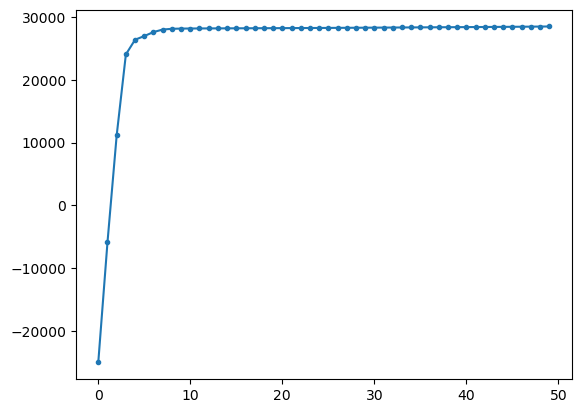

In [8]:
# Plot log-likelihood
plt.plot(log_likelihood[1:], marker='.')